# 🍽️ Hangout Place Recommendation System — Bangalore
**Dataset:** Zomato Bangalore Restaurants (~51,000 records)  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn · SQL  
**Author:** Somesh | MSc Data Analytics, Christ University

---
### Project Phases
| Phase | Description |
|-------|-------------|
| 1 | Data Loading & Cleaning |
| 2 | Feature Engineering |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Content-Based Recommendation Engine |
| 5 | SQL Filtering Layer |


## Phase 1 — Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['axes.edgecolor'] = '#e94560'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
PALETTE = ['#e94560','#f5a623','#50fa7b','#8be9fd','#bd93f9','#ff79c6','#ffb86c']

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('../data/zomato.csv')
print(f"Raw shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Raw shape: (51717, 17)

Columns:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

First 3 rows:


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


In [3]:
# Check nulls and data types
print("Null counts:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

Null counts:
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

Data types:
url                              str
address                          str
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
phone                            str
location                         str

In [4]:
# Drop irrelevant columns
df.drop(columns=['url', 'phone', 'address', 'reviews_list', 'menu_item'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)
print(f"After cleaning shape: {df.shape}")

# Clean 'rate': '4.1/5' -> 4.1
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False).str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost: remove commas
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str).str.replace(',', '', regex=False).str.strip()
)
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce'
)

# Rename columns for convenience
df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'listing_type',
    'listed_in(city)': 'city_area'
}, inplace=True)

# Fill nulls
df['rate'].fillna(df['rate'].median(), inplace=True)
df['cost_for_two'].fillna(df['cost_for_two'].median(), inplace=True)
df['rest_type'].fillna('Unknown', inplace=True)
df['cuisines'].fillna('Unknown', inplace=True)
df['dish_liked'].fillna('', inplace=True)
df['location'].fillna('Unknown', inplace=True)

print(f"\nFinal clean shape: {df.shape}")
print(f"\nRemaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

After cleaning shape: (51609, 12)

Final clean shape: (51609, 12)

Remaining nulls:
rate            10019
location           21
rest_type         227
dish_liked      28014
cuisines           45
cost_for_two      344
dtype: int64


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,cost_for_two,listing_type,city_area
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet,Banashankari


## Phase 2 — Feature Engineering

In [5]:
# Budget buckets
def budget_bucket(cost):
    if cost <= 300:   return 'Budget (<=300)'
    elif cost <= 600: return 'Mid-Range (301-600)'
    elif cost <= 1000: return 'Premium (601-1000)'
    else:             return 'Luxury (1000+)'

df['budget_category'] = df['cost_for_two'].apply(budget_bucket)
print("Budget categories:")
print(df['budget_category'].value_counts())

Budget categories:
budget_category
Mid-Range (301-600)    19177
Budget (<=300)         18515
Premium (601-1000)      8319
Luxury (1000+)          5598
Name: count, dtype: int64


In [6]:
# Occasion tags
def occasion_tag(row):
    lt = str(row['listing_type']).lower()
    rt = str(row['rest_type']).lower()
    tags = []
    if any(x in lt for x in ['dine-out', 'buffet']) or 'fine dining' in rt:
        tags.append('Date Night')
    if any(x in lt for x in ['cafe', 'desserts', 'drinks']):
        tags.append('Friends Hangout')
    if any(x in lt for x in ['buffet', 'dine-out']) or 'casual dining' in rt:
        tags.append('Family Outing')
    if any(x in lt for x in ['pubs', 'nightlife', 'drinks']):
        tags.append('Night Out')
    if any(x in rt for x in ['quick bites', 'delivery', 'mess']):
        tags.append('Solo / Quick Meal')
    if not tags:
        tags.append('General')
    return ', '.join(tags)

df['occasion_tags'] = df.apply(occasion_tag, axis=1)
print("Sample occasion tags:")
print(df['occasion_tags'].value_counts().head(8))

Sample occasion tags:
occasion_tags
Solo / Quick Meal                               15171
Date Night, Family Outing, Solo / Quick Meal     9435
Date Night, Family Outing                        9203
Family Outing                                    5641
General                                          5034
Friends Hangout                                  4161
Friends Hangout, Solo / Quick Meal                882
Friends Hangout, Night Out                        606
Name: count, dtype: int64


In [7]:
# Ambience mapping
def ambience_map(rest_type):
    rt = str(rest_type).lower()
    if 'fine dining' in rt:          return 'Upscale / Romantic'
    elif 'casual dining' in rt:      return 'Casual / Social'
    elif 'cafe' in rt:               return 'Cozy / Chill'
    elif 'pub' in rt or 'bar' in rt: return 'Lively / Party'
    elif 'quick bites' in rt or 'delivery' in rt: return 'Fast / Functional'
    elif 'dessert' in rt or 'bakery' in rt: return 'Sweet / Relaxed'
    else:                            return 'General'

df['ambience'] = df['rest_type'].apply(ambience_map)
print("Ambience distribution:")
print(df['ambience'].value_counts())

Ambience distribution:
ambience
Fast / Functional     25068
Casual / Social       13023
Cozy / Chill           4576
Sweet / Relaxed        3850
General                3403
Lively / Party         1286
Upscale / Romantic      403
Name: count, dtype: int64


In [8]:
# Preview engineered features
df[['name','location','cost_for_two','budget_category','occasion_tags','ambience']].head(10)

,name,location,cost_for_two,budget_category,occasion_tags,ambience
0,Jalsa,Banashankari,800.0,Premium (601-1000),"Date Night, Family Outing",Casual / Social
1,Spice Elephant,Banashankari,800.0,Premium (601-1000),"Date Night, Family Outing",Casual / Social
2,San Churro Cafe,Banashankari,800.0,Premium (601-1000),"Date Night, Family Outing",Casual / Social
3,Addhuri Udupi Bhojana,Banashankari,300.0,Budget (<=300),"Date Night, Family Outing, Solo / Quick Meal",Fast / Functional
4,Grand Village,Basavanagudi,600.0,Mid-Range (301-600),"Date Night, Family Outing",Casual / Social
5,Timepass Dinner,Basavanagudi,600.0,Mid-Range (301-600),"Date Night, Family Outing",Casual / Social
6,Rosewood International Hotel - Bar & Restaurant,Mysore Road,800.0,Premium (601-1000),"Date Night, Family Outing",Casual / Social
7,Onesta,Banashankari,600.0,Mid-Range (301-600),"Friends Hangout, Family Outing",Casual / Social
8,Penthouse Cafe,Banashankari,700.0,Premium (601-1000),Friends Hangout,Cozy / Chill
9,Smacznego,Banashankari,550.0,Mid-Range (301-600),Friends Hangout,Cozy / Chill


## Phase 3 — Exploratory Data Analysis (EDA)

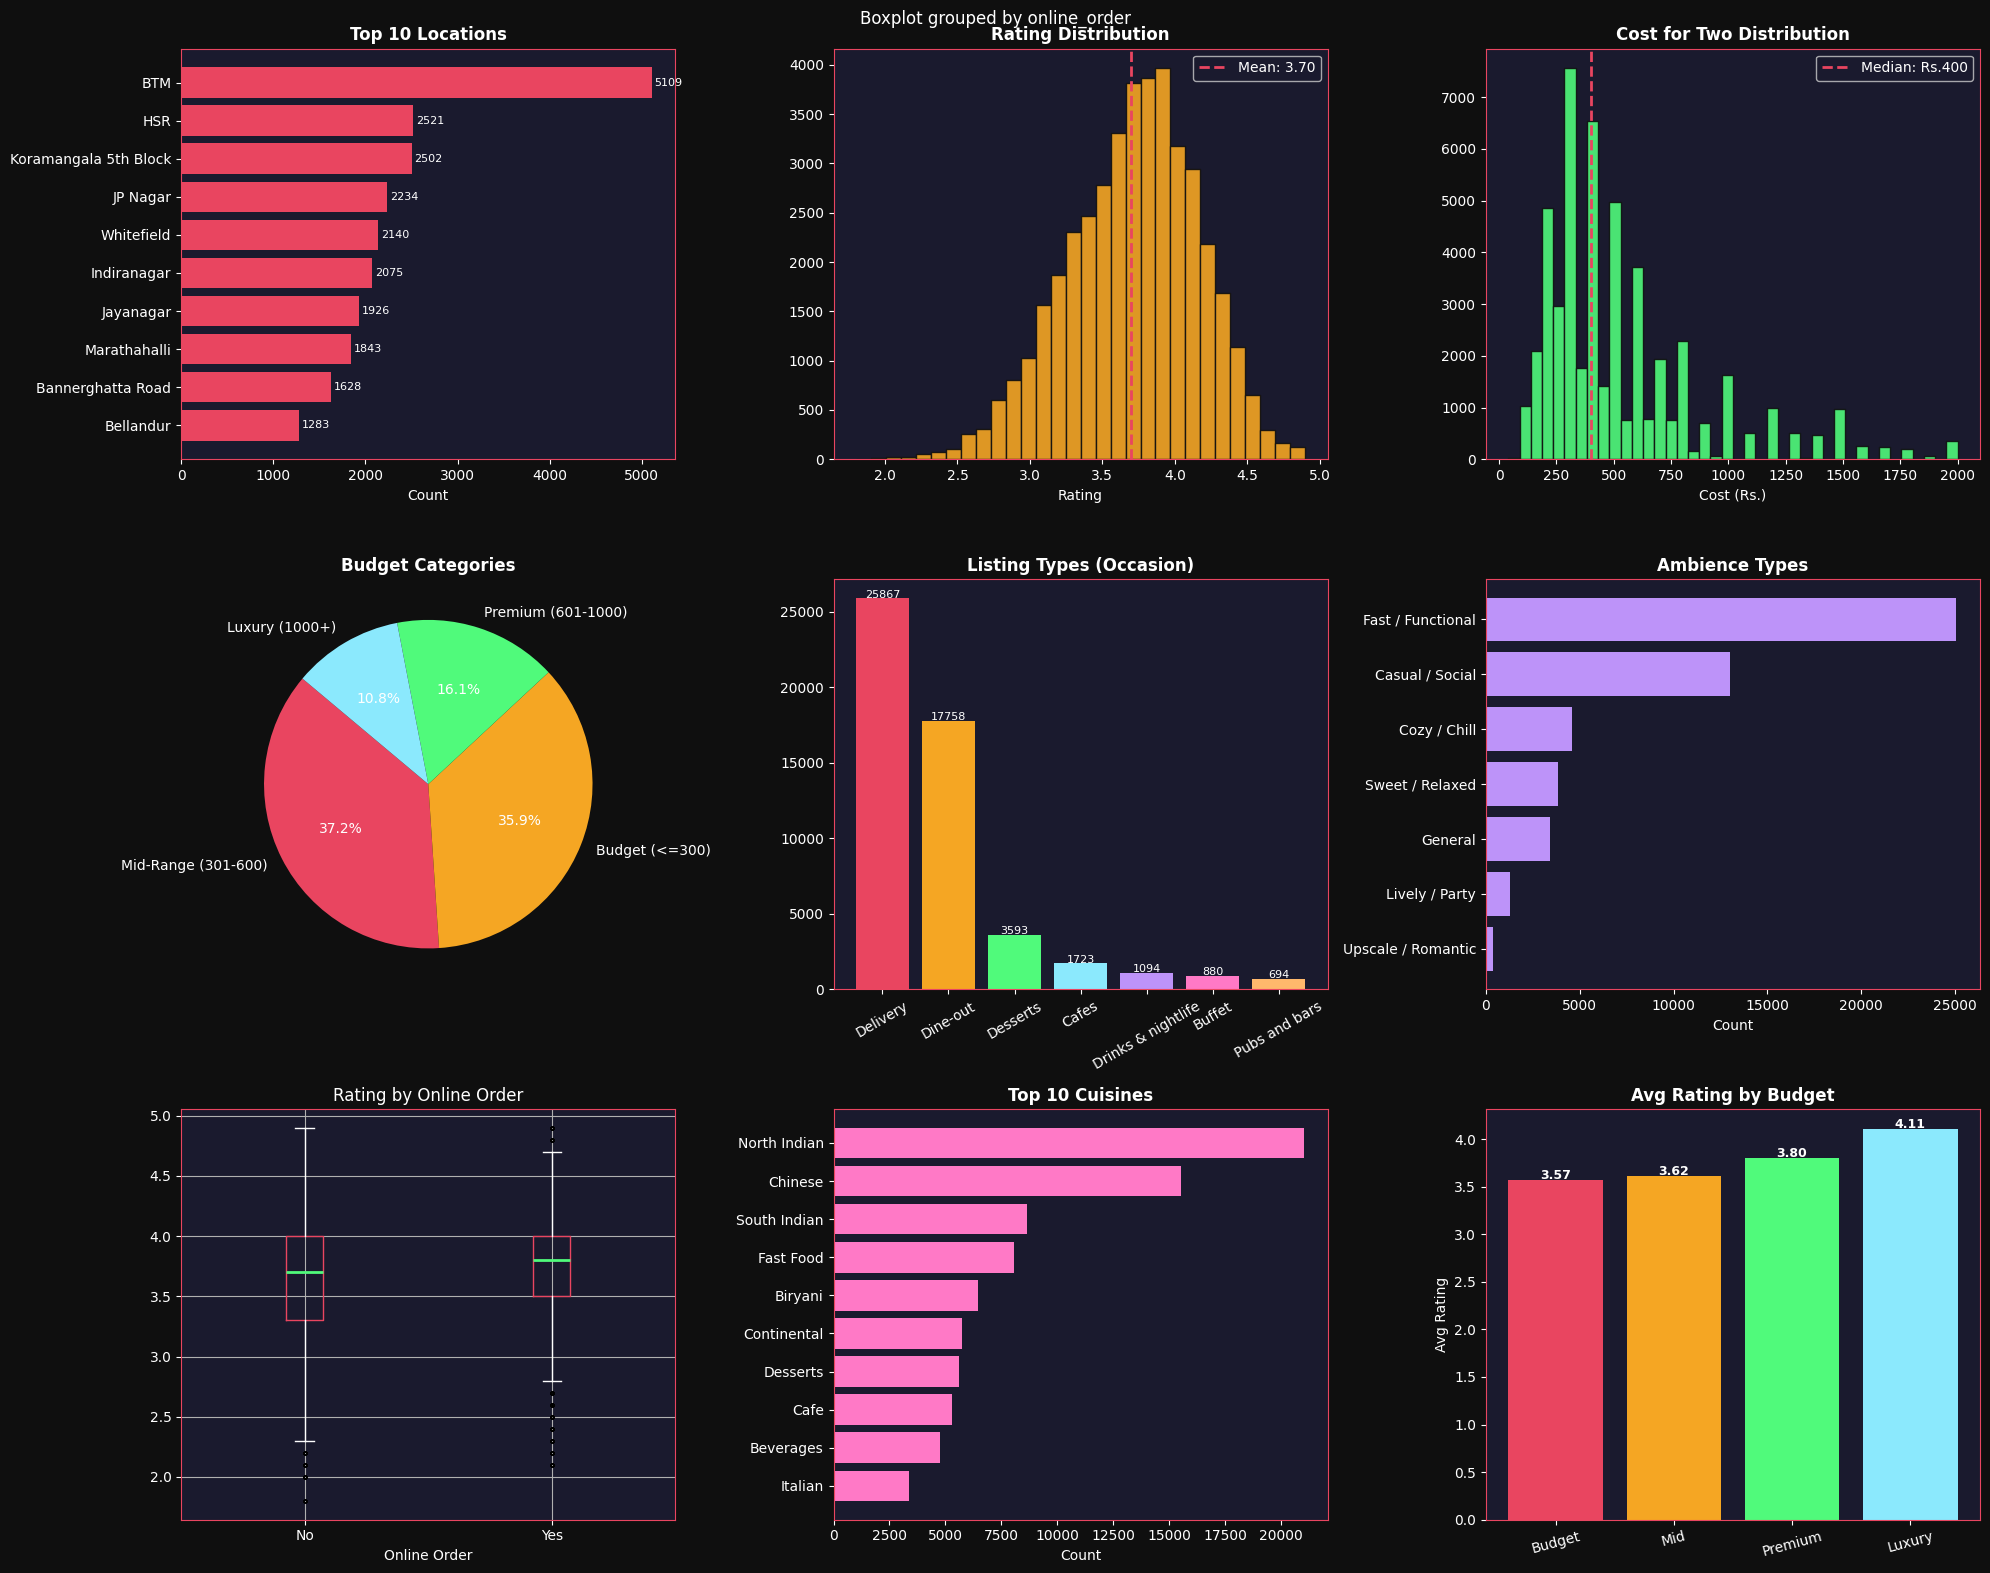

EDA chart saved to data/zomato_eda.png


In [9]:
# EDA — 9 Panel Dashboard
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Zomato Bangalore — Hangout Recommendation EDA',
             fontsize=20, color='white', fontweight='bold', y=1.01)

ACCENT = '#e94560'

# 1. Top 10 Locations
ax = axes[0, 0]
top_loc = df['location'].value_counts().head(10)
bars = ax.barh(top_loc.index[::-1], top_loc.values[::-1], color=PALETTE[0])
ax.set_title('Top 10 Locations', color='white', fontweight='bold')
ax.set_xlabel('Count', color='white')
for bar, val in zip(bars, top_loc.values[::-1]):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
            str(val), va='center', color='white', fontsize=8)

# 2. Rating Distribution
ax = axes[0, 1]
ax.hist(df['rate'], bins=30, color=PALETTE[1], edgecolor='#0f0f0f', alpha=0.9)
ax.axvline(df['rate'].mean(), color=ACCENT, linestyle='--', linewidth=2,
           label=f"Mean: {df['rate'].mean():.2f}")
ax.set_title('Rating Distribution', color='white', fontweight='bold')
ax.set_xlabel('Rating', color='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')

# 3. Cost Distribution
ax = axes[0, 2]
cost_f = df[df['cost_for_two'] <= 2000]['cost_for_two']
ax.hist(cost_f, bins=40, color=PALETTE[2], edgecolor='#0f0f0f', alpha=0.9)
ax.axvline(cost_f.median(), color=ACCENT, linestyle='--', linewidth=2,
           label=f"Median: Rs.{cost_f.median():.0f}")
ax.set_title('Cost for Two Distribution', color='white', fontweight='bold')
ax.set_xlabel('Cost (Rs.)', color='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')

# 4. Budget Category Pie
ax = axes[1, 0]
bc = df['budget_category'].value_counts()
wedges, texts, autotexts = ax.pie(bc.values, labels=bc.index, autopct='%1.1f%%',
    colors=PALETTE[:4], textprops={'color':'white'}, startangle=140)
for a in autotexts: a.set_color('white')
ax.set_title('Budget Categories', color='white', fontweight='bold')

# 5. Listing Types
ax = axes[1, 1]
lt = df['listing_type'].value_counts()
bars = ax.bar(lt.index, lt.values, color=PALETTE[:len(lt)])
ax.set_title('Listing Types (Occasion)', color='white', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, lt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            str(val), ha='center', color='white', fontsize=8)

# 6. Ambience Distribution
ax = axes[1, 2]
amb = df['ambience'].value_counts()
ax.barh(amb.index[::-1], amb.values[::-1], color=PALETTE[4])
ax.set_title('Ambience Types', color='white', fontweight='bold')
ax.set_xlabel('Count', color='white')

# 7. Online Order vs Rating
ax = axes[2, 0]
df.boxplot(column='rate', by='online_order', ax=ax,
    boxprops=dict(color=ACCENT), whiskerprops=dict(color='white'),
    medianprops=dict(color=PALETTE[2], linewidth=2),
    capprops=dict(color='white'),
    flierprops=dict(color=ACCENT, marker='o', markersize=2))
ax.set_title('Rating by Online Order', color='white', fontweight='bold')
ax.set_xlabel('Online Order', color='white')
plt.sca(ax); plt.title('Rating by Online Order', color='white')

# 8. Top 10 Cuisines
ax = axes[2, 1]
cuisine_series = df['cuisines'].str.split(', ').explode()
top_c = cuisine_series.value_counts().head(10)
ax.barh(top_c.index[::-1], top_c.values[::-1], color=PALETTE[5])
ax.set_title('Top 10 Cuisines', color='white', fontweight='bold')
ax.set_xlabel('Count', color='white')

# 9. Avg Rating by Budget
ax = axes[2, 2]
budget_order = ['Budget (<=300)','Mid-Range (301-600)','Premium (601-1000)','Luxury (1000+)']
avg_r = df.groupby('budget_category')['rate'].mean().reindex(budget_order)
bars = ax.bar(range(4), avg_r.values, color=PALETTE[:4])
ax.set_xticks(range(4))
ax.set_xticklabels(['Budget','Mid','Premium','Luxury'], rotation=15, color='white')
ax.set_title('Avg Rating by Budget', color='white', fontweight='bold')
ax.set_ylabel('Avg Rating', color='white')
for bar, val in zip(bars, avg_r.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.2f}', ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/zomato_eda.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("EDA chart saved to data/zomato_eda.png")

### Key EDA Insights

In [10]:
# Quick stats summary
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total restaurants       : {len(df):,}")
print(f"Unique locations        : {df['location'].nunique()}")
print(f"Unique cuisines         : {df['cuisines'].str.split(', ').explode().nunique()}")
print(f"Average rating          : {df['rate'].mean():.2f} / 5")
print(f"Median cost for two     : Rs. {df['cost_for_two'].median():.0f}")
print(f"Online order available  : {(df['online_order']=='Yes').sum():,} restaurants")
print(f"Table booking available : {(df['book_table']=='Yes').sum():,} restaurants")
print()
print("Top 5 locations:")
print(df['location'].value_counts().head(5).to_string())
print()
print("Top 5 cuisines:")
print(df['cuisines'].str.split(', ').explode().value_counts().head(5).to_string())

DATASET OVERVIEW
Total restaurants       : 51,609
Unique locations        : 93
Unique cuisines         : 107
Average rating          : 3.70 / 5
Median cost for two     : Rs. 400
Online order available  : 30,361 restaurants
Table booking available : 6,416 restaurants

Top 5 locations:
location
BTM                      5109
HSR                      2521
Koramangala 5th Block    2502
JP Nagar                 2234
Whitefield               2140

Top 5 cuisines:
cuisines
North Indian    21043
Chinese         15516
South Indian     8633
Fast Food        8084
Biryani          6475


## Phase 4 — Content-Based Recommendation Engine

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Build combined feature string per restaurant
def build_features(row):
    parts = [
        str(row['cuisines']),
        str(row['rest_type']),
        str(row['listing_type']),
        str(row['ambience']),
        str(row['budget_category']),
        str(row['dish_liked'])
    ]
    return ' '.join(parts).lower()

df['features'] = df.apply(build_features, axis=1)

# Fit TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['features'])

df.reset_index(drop=True, inplace=True)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print("Recommendation engine ready!")

TF-IDF matrix shape: (51609, 1487)
Recommendation engine ready!


In [12]:
def recommend(
    occasion='Date Night',
    budget='Mid-Range (301-600)',
    cuisine=None,
    location=None,
    top_n=10
):
    """
    Recommend hangout places based on preferences.

    Parameters
    ----------
    occasion : str
        'Date Night' | 'Friends Hangout' | 'Family Outing' | 'Night Out' | 'Solo / Quick Meal'
    budget : str
        'Budget (<=300)' | 'Mid-Range (301-600)' | 'Premium (601-1000)' | 'Luxury (1000+)'
    cuisine : str, optional
        e.g. 'North Indian', 'Chinese', 'Italian', 'Continental'
    location : str, optional
        Bangalore area e.g. 'Indiranagar', 'Koramangala 5th Block', 'HSR'
    top_n : int
        Number of recommendations to return
    """
    query_parts = [occasion, budget]
    if cuisine:  query_parts.append(cuisine)
    query = ' '.join(query_parts).lower()

    query_vec  = tfidf.transform([query])
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    filtered = df.copy()
    filtered['sim_score'] = sim_scores

    if location:
        filtered = filtered[
            filtered['location'].str.lower().str.contains(location.lower(), na=False)
        ]
    if budget:
        filtered = filtered[filtered['budget_category'] == budget]

    filtered['final_score'] = (
        filtered['sim_score'] * 0.6 +
        (filtered['rate'] / 5) * 0.4
    )

    result = (filtered
              .sort_values('final_score', ascending=False)
              .drop_duplicates(subset='name')
              .head(top_n)
              [['name','location','cuisines','rate','votes',
                'cost_for_two','ambience','budget_category',
                'online_order','book_table','occasion_tags']])
    return result

print("recommend() function defined!")

recommend() function defined!


### Test the Recommender

In [13]:
# Test 1: Date Night — Premium
print("=" * 60)
print("Date Night | Premium | Italian")
print("=" * 60)
result = recommend(
    occasion='Date Night',
    budget='Premium (601-1000)',
    cuisine='Italian',
    top_n=5
)
result[['name','location','cuisines','rate','cost_for_two','ambience']]

Date Night | Premium | Italian


,name,location,cuisines,rate,cost_for_two,ambience
25310,Eagles Pizza,Kalyan Nagar,"Pizza, Italian",3.8,650.0,Fast / Functional
27774,Wild Thyme Restaurant,Koramangala 5th Block,"Chinese, Continental, North Indian, Italian, S...",4.5,800.0,Casual / Social
21300,Wudfyr,JP Nagar,"Fast Food, Italian, North Indian, Steak",3.8,700.0,Fast / Functional
50513,Nieghbourhood Cafe,Whitefield,"Pizza, Italian, Chinese, North Indian",3.7,750.0,Casual / Social
9169,Pipabu,Koramangala 4th Block,"Continental, Italian, Chinese",3.8,750.0,Casual / Social


In [14]:
# Test 2: Friends Hangout in Indiranagar
print("=" * 60)
print("Friends Hangout | Mid-Range | Indiranagar")
print("=" * 60)
result = recommend(
    occasion='Friends Hangout',
    budget='Mid-Range (301-600)',
    location='Indiranagar',
    top_n=5
)
result[['name','location','cuisines','rate','cost_for_two','ambience']]

Friends Hangout | Mid-Range | Indiranagar


,name,location,cuisines,rate,cost_for_two,ambience
5213,YumYumDilli,Indiranagar,North Indian,3.6,500.0,Fast / Functional
42880,Habib's Biryani,Indiranagar,Biryani,3.6,400.0,Fast / Functional
44793,Food Lover,Indiranagar,"North Indian, Chinese",3.7,400.0,Fast / Functional
45018,Kulcha Kulture,Indiranagar,North Indian,3.5,400.0,Fast / Functional
18120,Eat Well,Indiranagar,"North Indian, Chinese",3.5,400.0,Fast / Functional


In [15]:
# Test 3: Family outing, budget North Indian
print("=" * 60)
print("Family Outing | Budget | North Indian")
print("=" * 60)
result = recommend(
    occasion='Family Outing',
    budget='Budget (<=300)',
    cuisine='North Indian',
    top_n=5
)
result[['name','location','cuisines','rate','cost_for_two','ambience']]

Family Outing | Budget | North Indian


,name,location,cuisines,rate,cost_for_two,ambience
2939,Parathe Wali Gali,Wilson Garden,North Indian,3.9,250.0,Fast / Functional
8786,Chapati House,Ejipura,North Indian,3.9,300.0,Fast / Functional
13599,Uma Ki Rasoi,Electronic City,North Indian,3.9,250.0,Fast / Functional
46092,Sri Ayodhya Veg,Vijay Nagar,"South Indian, North Indian",4.0,300.0,Fast / Functional
30455,King Punjabi Restaurant,BTM,North Indian,3.8,300.0,Fast / Functional


In [16]:
# Test 4: Night Out — Koramangala
print("=" * 60)
print("Night Out | Mid-Range | Koramangala")
print("=" * 60)
result = recommend(
    occasion='Night Out',
    budget='Mid-Range (301-600)',
    location='Koramangala',
    top_n=5
)
result[['name','location','cuisines','rate','cost_for_two','ambience']]

Night Out | Mid-Range | Koramangala


,name,location,cuisines,rate,cost_for_two,ambience
8621,YumYumDilli,Koramangala 7th Block,North Indian,3.7,500.0,Fast / Functional
33516,Halo Chef,Koramangala 4th Block,North Indian,3.9,500.0,Fast / Functional
29667,Foreign CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ©,Koramangala 7th Block,Continental,3.8,500.0,Fast / Functional
32715,Foreign CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ...,Koramangala 7th Block,Continental,3.8,500.0,Fast / Functional
33107,India On Wheels,Koramangala 3rd Block,North Indian,3.6,400.0,Fast / Functional


## Phase 5 — SQL Filtering Layer
Using Python's `sqlite3` to create an in-memory SQL database for structured queries on top of the recommendation engine.


In [17]:
import sqlite3

# Load cleaned data into SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('restaurants', conn, index=False, if_exists='replace')
print("SQLite database created with 'restaurants' table.")
print(f"Rows loaded: {pd.read_sql('SELECT COUNT(*) as total FROM restaurants', conn).iloc[0,0]:,}")

SQLite database created with 'restaurants' table.
Rows loaded: 51,609


In [18]:
# SQL Query 1: Best rated budget restaurants
query1 = '''
SELECT name, location, cuisines, rate, cost_for_two, ambience
FROM restaurants
WHERE budget_category = 'Budget (<=300)'
  AND rate >= 4.0
  AND online_order = 'Yes'
ORDER BY rate DESC, votes DESC
LIMIT 10
'''
pd.read_sql(query1, conn)

,name,location,cuisines,rate,cost_for_two,ambience
0,CTR,Malleshwaram,South Indian,4.8,150.0,Fast / Functional
1,CTR,Malleshwaram,South Indian,4.8,150.0,Fast / Functional
2,CTR,Malleshwaram,South Indian,4.7,150.0,Fast / Functional
3,CTR,Malleshwaram,South Indian,4.7,150.0,Fast / Functional
4,The Pancake Story,Koramangala 1st Block,"Desserts, Beverages",4.6,300.0,Sweet / Relaxed
5,The Pancake Story,Koramangala 1st Block,"Desserts, Beverages",4.6,300.0,Sweet / Relaxed
6,The Pancake Story,Koramangala 1st Block,"Desserts, Beverages",4.6,300.0,Sweet / Relaxed
7,The Pancake Story,Koramangala 1st Block,"Desserts, Beverages",4.6,300.0,Sweet / Relaxed
8,The Pancake Story,Koramangala 1st Block,"Desserts, Beverages",4.6,300.0,Sweet / Relaxed
9,The Pancake Story,Koramangala 1st Block,"Desserts, Beverages",4.6,300.0,Sweet / Relaxed


In [19]:
# SQL Query 2: Date Night spots in Koramangala with table booking
query2 = '''
SELECT name, location, cuisines, rate, cost_for_two, ambience
FROM restaurants
WHERE occasion_tags LIKE '%Date Night%'
  AND location LIKE '%Koramangala%'
  AND book_table = 'Yes'
ORDER BY rate DESC
LIMIT 10
'''
pd.read_sql(query2, conn)

,name,location,cuisines,rate,cost_for_two,ambience
0,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
1,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
2,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
3,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
4,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
5,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
6,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
7,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
8,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social
9,Asia Kitchen By Mainland China,Koramangala 5th Block,"Asian, Chinese, Thai, Momos",4.9,1500.0,Casual / Social


In [20]:
# SQL Query 3: Top cuisines by average rating
query3 = '''
SELECT cuisines, 
       ROUND(AVG(rate), 2) AS avg_rating,
       COUNT(*) AS total_restaurants
FROM restaurants
WHERE cuisines != 'Unknown'
GROUP BY cuisines
HAVING total_restaurants > 20
ORDER BY avg_rating DESC
LIMIT 15
'''
pd.read_sql(query3, conn)

,cuisines,avg_rating,total_restaurants
0,"North Indian, Thai, Japanese, Continental, Cafe",4.69,34
1,"Cafe, American, Burger, Steak",4.60,43
2,"American, North Indian, Chinese, Finger Food",4.60,24
3,"Italian, Pizza, Salad",4.50,28
4,"Continental, Asian, North Indian",4.50,25
5,"North Indian, European, Mediterranean, BBQ, Kebab",4.49,41
6,"Healthy Food, North Indian, Biryani, Continent...",4.49,29
7,"European, Continental",4.49,23
8,"Cafe, Desserts, Continental",4.49,24
9,"Ice Cream, Cafe, Pizza, Burger, Desserts, Beve...",4.42,33


In [21]:
# SQL Query 4: Location summary - avg cost and rating
query4 = '''
SELECT location,
       COUNT(*) AS total,
       ROUND(AVG(rate), 2) AS avg_rating,
       ROUND(AVG(cost_for_two), 0) AS avg_cost
FROM restaurants
GROUP BY location
HAVING total > 100
ORDER BY avg_rating DESC
LIMIT 15
'''
pd.read_sql(query4, conn)

,location,total,avg_rating,avg_cost
0,Lavelle Road,524,4.14,1307.0
1,St. Marks Road,352,4.02,871.0
2,Koramangala 3rd Block,215,4.02,778.0
3,Koramangala 5th Block,2502,4.01,664.0
4,Church Street,566,3.99,835.0
5,Koramangala 4th Block,1017,3.92,696.0
6,Cunningham Road,490,3.90,865.0
7,Residency Road,672,3.86,964.0
8,MG Road,917,3.86,1156.0
9,Koramangala 7th Block,1179,3.85,593.0


## Save Clean Dataset

In [22]:
# Save the cleaned + engineered dataset
df.to_csv('../data/zomato_clean.csv', index=False)
print(f"Saved zomato_clean.csv — shape: {df.shape}")
print("\nFinal columns:")
for col in df.columns:
    print(f"  {col}")

Saved zomato_clean.csv — shape: (51609, 16)

Final columns:
  name
  online_order
  book_table
  rate
  votes
  location
  rest_type
  dish_liked
  cuisines
  cost_for_two
  listing_type
  city_area
  budget_category
  occasion_tags
  ambience
  features


---
## Project Summary

| Phase | Status | Output |
|-------|--------|--------|
| 1. Data Cleaning | ✅ Done | 51,609 clean records |
| 2. Feature Engineering | ✅ Done | budget_category, occasion_tags, ambience |
| 3. EDA | ✅ Done | 9-panel dashboard |
| 4. ML Recommender | ✅ Done | TF-IDF content-based engine |
| 5. SQL Layer | ✅ Done | SQLite in-memory queries |

**Next Steps:**
- Build a Streamlit web app for interactive recommendations
- Add collaborative filtering using votes/ratings
- Deploy to Streamlit Cloud or Hugging Face Spaces
